In [ ]:
import pandas as pd
import os

save_folders = ["2025_09_04_beta1.0_2BS_20UE_10RIS_250M", "2025_09_04_beta1.2_2BS_20UE_10RIS_250M", "2025_09_04_beta1.5_2BS_20UE_10RIS_250M",
                "2025_09_04_beta2.0_2BS_20UE_10RIS_250M", "2025_09_04_beta3.0_2BS_20UE_10RIS_250M", "2025_09_04_beta4.0_2BS_20UE_10RIS_250M",
                "2025_09_04_beta5.0_2BS_20UE_10RIS_250M", "2025_09_04_beta7.0_2BS_20UE_10RIS_250M", "2025_09_04_beta10.0_2BS_20UE_10RIS_250M",
                "2025_09_04_beta12.0_2BS_20UE_10RIS_250M", "2025_09_04_beta15.0_2BS_20UE_10RIS_250M", "2025_09_04_beta18.0_2BS_20UE_10RIS_250M"]

save_folders = [os.path.join(os.pardir, "results", folder) for folder in save_folders]
file_name = "Data.csv"

for i, folder in enumerate(save_folders):
    df = pd.read_csv(os.path.join(folder, file_name), index_col=0)
    df["Efficiency"] = df["Sum rate"] / df["Cost"]
    if i == 0:
        data = df
    else:
        data = data._append(df.iloc[0])

data.sort_index(inplace=True)
data


,Sum rate,Cost,Number of RISs allocated,Bid value,Efficiency
Distance-based,6.824846,0.559875,3.2875,0.593086,12.189946
Greedy,7.040060,0.598000,3.2175,0.784477,11.772675
RL beta 1.0,7.395703,0.893375,4.3900,0.684815,8.278385
RL beta 1.2,7.436585,0.833375,4.2525,0.742054,8.923456
RL beta 1.5,7.326845,0.850625,4.2100,0.718712,8.613485
RL beta 10.0,6.154898,0.117375,2.2550,0.813649,52.437898
RL beta 12.0,6.246259,0.108250,2.1625,0.847274,57.702162
RL beta 15.0,6.117149,0.081250,1.6225,0.942760,75.287987
RL beta 18.0,5.699869,0.058625,1.1725,0.989169,97.225919
RL beta 2.0,7.426653,0.729625,3.9650,0.802174,10.178725


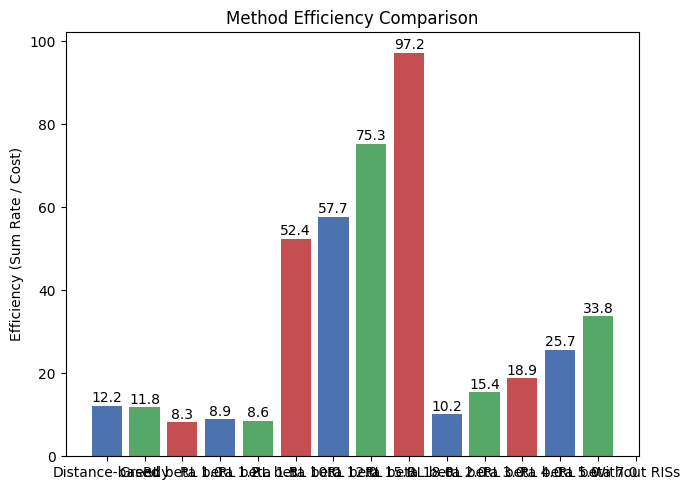

In [ ]:
import matplotlib.pyplot as plt

df = data

plt.figure(figsize=(7,5))
bars = plt.bar(df.index, df["Efficiency"], color=["#4C72B0", "#55A868", "#C44E52"])
plt.ylabel("Efficiency (Sum Rate / Cost)")

# Add value labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f"{yval:.1f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("efficiency", dpi=300, bbox_inches="tight")  
plt.show()

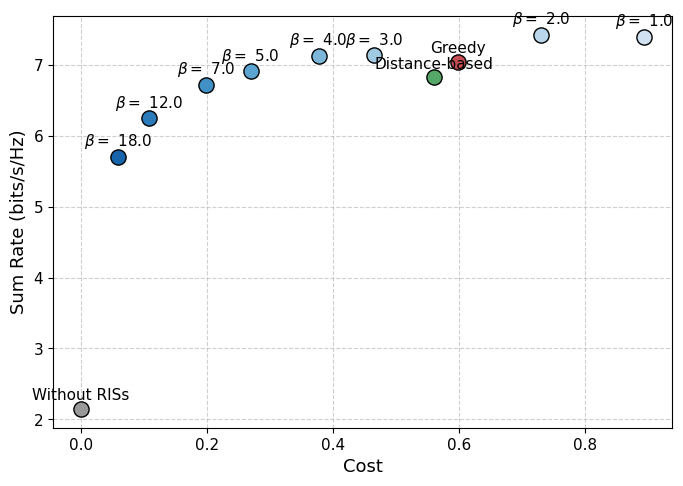

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 11,       # default text size
    "axes.labelsize": 13,  # x/y-axis labels
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11  # legend text size
})

# --- Filter out unwanted models ---
df_plot = df.drop(index=["RL beta 1.2", "RL beta 1.5", "RL beta 10.0", "RL beta 15.0"], errors="ignore")

plt.figure(figsize=(7,5))

# --- Assign colors by method family ---
colors = {}
colors["Distance-based"] = "#55A868"   # green
colors["Greedy"] = "#C44E52"           # red
colors["Without RISs"] = "#999999"     # grey

# RL models with stronger gradient
rl_methods = [m for m in df_plot.index if "RL beta" in m]
blue_cmap = plt.cm.Blues(np.linspace(0.2, 0.8, len(rl_methods)))
for method, c in zip(sorted(rl_methods, key=lambda x: float(x.split()[2])), blue_cmap):
    colors[method] = c

# --- Plot points ---
for i, (method_name, row) in enumerate(df_plot.iterrows()):
    plt.scatter(row["Cost"], row["Sum rate"],
                color=colors[method_name], s=120, edgecolors="black", zorder=3)

# --- Annotate: use Greek β for RL models ---
for method_name, row in df_plot.iterrows():
    label = method_name
    if "RL beta" in method_name:
        val = method_name.split()[-1]   # get the numeric part
        label = rf"$\beta=$ {val}"       # LaTeX string with Greek beta
    
    dy = 0.08   # vertical offset
    plt.text(row["Cost"], row["Sum rate"]+dy,
             label, ha="center", va="bottom")


# --- Labels and styling ---
plt.xlabel("Cost")
plt.ylabel("Sum Rate (bits/s/Hz)")
plt.grid(True, linestyle="--", alpha=0.6, zorder=0)
plt.tight_layout()

plt.savefig("cost_vs_sum_rate.png", dpi=300, bbox_inches="tight")
plt.show()


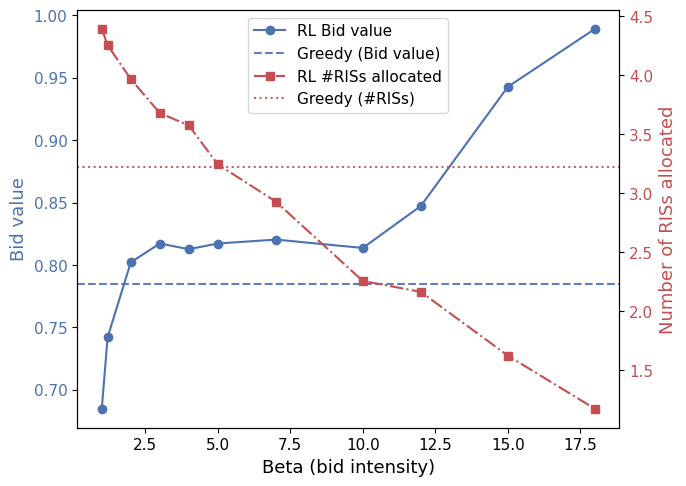

In [4]:
import matplotlib.pyplot as plt

# --- Extract RL runs ---
rl_df = df[df.index.str.contains("RL beta")].copy()
rl_df["beta"] = [float(rl_df.index[i].split(" ")[2]) for i in range(len(rl_df))]
rl_df = rl_df.drop(index=["RL beta 1.5"], errors="ignore")

rl_df.sort_values("beta", inplace=True)

# --- Baselines ---
baseline_df = df[~df.index.str.contains("RL beta")]
# Drop "Without RISs" row
baseline_df = baseline_df[~baseline_df.index.isin(["Without RISs", "Distance-based"])]

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(7,5))

color1 = "#4C72B0"   # bid value
color2 = "#C44E52"   # RISs allocated

# Left y-axis: Bid value
ax1.plot(rl_df["beta"], rl_df["Bid value"], marker="o", color=color1, label="RL Bid value")
ax1.set_xlabel("Beta (bid intensity)")
ax1.set_ylabel("Bid value", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

# Add baseline horizontal lines for Bid value
for method, row in baseline_df.iterrows():
    ax1.axhline(y=row["Bid value"], linestyle="--", alpha=0.9,
                color=color1, label=f"{method} (Bid value)")

# Right y-axis: Number of RISs allocated
ax2 = ax1.twinx()
ax2.plot(rl_df["beta"], rl_df["Number of RISs allocated"], marker="s", linestyle="-.",
         color=color2, label="RL #RISs allocated")
ax2.set_ylabel("Number of RISs allocated", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

# Add baseline horizontal lines for RISs allocated
for method, row in baseline_df.iterrows():
    ax2.axhline(y=row["Number of RISs allocated"], linestyle=":", alpha=0.9,
                color=color2, label=f"{method} (#RISs)")

fig.tight_layout()

# Deduplicate legend entries
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
by_label = dict(zip(labels1+labels2, handles1+handles2))
ax1.legend(by_label.values(), by_label.keys(), loc="upper center")

plt.savefig("beta_effects_with_baselines", dpi=300, bbox_inches="tight")
plt.show()


<Figure size 700x500 with 0 Axes>

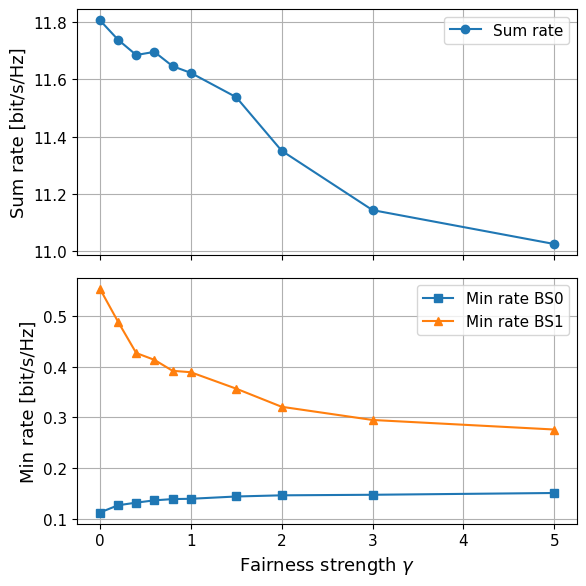

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
csv_path = "../results/2025_11_20_beta2_2BS_20UE_10RIS_250M/Data_gamma_200.csv"
df = pd.read_csv(csv_path)

plt.rcParams.update({
    "font.size": 11,       # default text size
    "axes.labelsize": 13,  # x/y-axis labels
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11  # legend text size
})

plt.figure(figsize=(7,5))

gamma = df["Gamma"]
sum_rate = df["Sum rate"]
min_bs0 = df["Min rate BS0"]
min_bs1 = df["Min rate BS1"]

# Create two-panel figure
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, sharex=True, figsize=(6, 6))

# --- Top panel: sum rate ---
ax_top.plot(gamma, sum_rate, marker="o", label="Sum rate")
ax_top.set_ylabel("Sum rate [bit/s/Hz]")
ax_top.grid(True)
ax_top.legend(loc="best")

# --- Bottom panel: min rates ---
ax_bottom.plot(gamma, min_bs0, marker="s", label="Min rate BS0")
ax_bottom.plot(gamma, min_bs1, marker="^", label="Min rate BS1")
ax_bottom.set_xlabel("Fairness strength $\\gamma$")
ax_bottom.set_ylabel("Min rate [bit/s/Hz]")
ax_bottom.grid(True)
ax_bottom.legend(loc="best")

plt.tight_layout()
plt.show()

"""Impact of the fairness strength parameter 𝛾 on system performance. The top panel shows the achievable sum rate, while the bottom panel shows the minimum user rates of BS0 and BS1. Increasing 𝛾 improves the minimum rate of the overloaded base station at the cost of a moderate reduction in minimum rate of the other base station."""

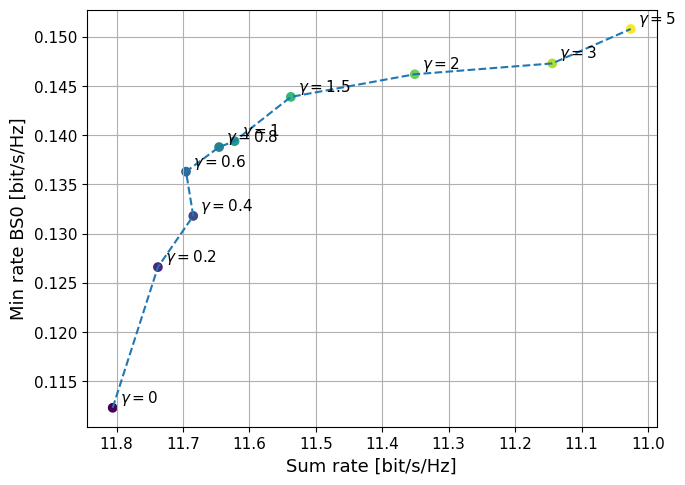

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
csv_path = "../results/2025_11_20_beta2_2BS_20UE_10RIS_250M/Data_gamma_200.csv"
df = pd.read_csv(csv_path)

plt.rcParams.update({
    "font.size": 11,       # default text size
    "axes.labelsize": 13,  # x/y-axis labels
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11  # legend text size
})

plt.figure(figsize=(7,5))

# Extract values
sum_rate = df["Sum rate"].values
min_bs0 = df["Min rate BS0"].values
gamma = df["Gamma"].values

# Sort by gamma
order = np.argsort(gamma)
sum_rate = sum_rate[order]
min_bs0 = min_bs0[order]
gamma = gamma[order]

# Linear index-based coloring
color_idx = np.arange(len(gamma))

sc = plt.scatter(
    sum_rate,
    min_bs0,
    c=color_idx,
    cmap="viridis",
    marker="o"
)

# Connect points
plt.plot(sum_rate, min_bs0, linestyle="--")

# Annotate gamma values
for x, y, g in zip(sum_rate, min_bs0, gamma):
    plt.annotate(
        f"$\\gamma={g:g}$",
        (x, y),
        textcoords="offset points",
        xytext=(5, 4),
    )

# Axis labels
plt.xlabel("Sum rate [bit/s/Hz]")
plt.ylabel("Min rate BS0 [bit/s/Hz]")

# Reverse x-axis
plt.gca().invert_xaxis()

plt.grid(True)
plt.tight_layout()
plt.savefig("min_vs_sum_rate.png", dpi=300, bbox_inches="tight")
plt.show()


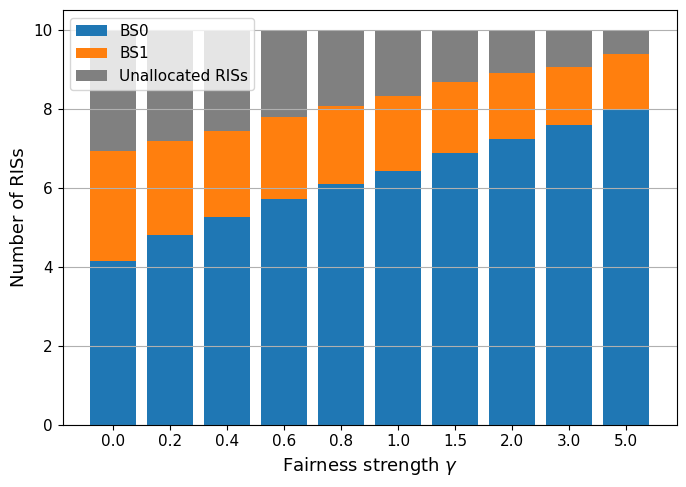

'Fig. 3 illustrates the average RIS allocation as a function of the fairness parameter γ. Increasing γ shifts RIS resources from BS1 to the overloaded BS0, while also decreasing the number of unallocated RISs due to more aggressive bidding behavior.'

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
csv_path = "../results/2025_11_20_beta2_2BS_20UE_10RIS_250M/Data_gamma_200.csv"
df = pd.read_csv(csv_path)

plt.rcParams.update({
    "font.size": 11,       # default text size
    "axes.labelsize": 13,  # x/y-axis labels
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11  # legend text size
})

plt.figure(figsize=(7,5))

gamma = df["Gamma"].values
x = np.arange(len(gamma))

# RIS allocations
nris_bs0 = df["#RISs allocated BS0"].values
nris_bs1 = df["#RIS allocated BS1"].values

total_ris = 10  # known total number of RISs
nris_unallocated = total_ris - (nris_bs0 + nris_bs1)

# Stacked bars
plt.bar(x, nris_bs0, label="BS0")
plt.bar(x, nris_bs1, bottom=nris_bs0, label="BS1")
plt.bar(
    x,
    nris_unallocated,
    bottom=nris_bs0 + nris_bs1,
    label="Unallocated RISs",
    color="gray"
)

# Axes and labels
plt.xticks(x, [f"{g:.1f}" for g in gamma])
plt.xlabel("Fairness strength $\\gamma$")
plt.ylabel("Number of RISs")
plt.legend()
plt.grid(True, axis="y")

plt.tight_layout()
plt.savefig("RIS_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

"""Fig. 3 illustrates the average RIS allocation as a function of the fairness parameter γ. Increasing γ shifts RIS resources from BS1 to the overloaded BS0, while also decreasing the number of unallocated RISs due to more aggressive bidding behavior."""


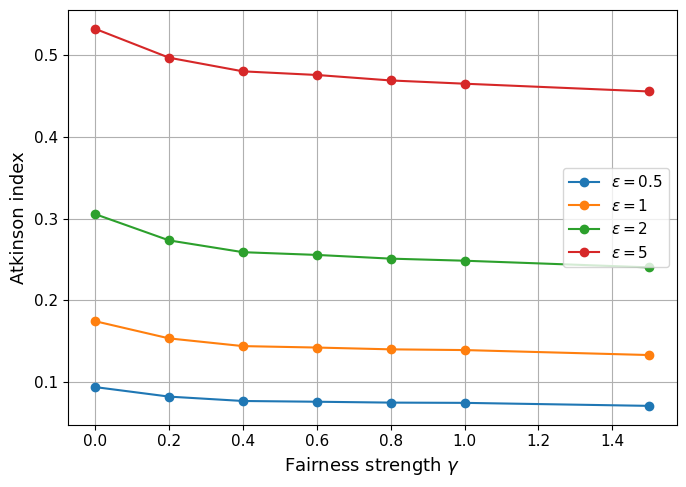

'Fig. 4 reports the Atkinson inequality index as a function of the fairness strength γ for multiple values of ϵ, which controls sensitivity to low-rate users. For all ϵ, increasing γ reduces inequality, confirming that the proposed mechanism improves fairness. Larger ϵ yields higher Atkinson values because the metric places greater weight on the worst-served users, thereby penalizing residual disparities more strongly'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def atkinson_inequality(x: np.ndarray, epsilon: float) -> float:
    """
    Atkinson inequality index A_epsilon for a 1D nonnegative vector x.
    Returns A in [0, 1], where 0 means perfect equality.
    """
    x = np.asarray(x, dtype=float)
    mu = np.mean(x)

    if np.isclose(epsilon, 1.0):
        A = 1 - 1 / mu * np.prod(x)**(1.0 / len(x))
    else:
        A = 1 - 1 / mu * (1 / len(x) * np.sum(x**(1.0 - epsilon)))**(1.0 / (1.0 - epsilon))

    # numerical safety
    return float(np.clip(A, 0.0, 1.0))


# -----------------------------
# Load npz results
# -----------------------------
data_path = "../results/2025_11_20_beta2_2BS_20UE_10RIS_250M/fairness_results_200eps.npz"
data = np.load(data_path)

plt.rcParams.update({
    "font.size": 11,       # default text size
    "axes.labelsize": 13,  # x/y-axis labels
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11  # legend text size
})

plt.figure(figsize=(7,5))

gammas = data["gammas"]                      # (n_gammas,)
SINR = data["SINR"]                          # (n_gammas, eval_episodes, N_UE, N_OP, NN)
BS_UE_assoc = data["BS_UE_assoc"]            # (n_gammas, eval_episodes, N_UE, N_OP)

# Convert SINR(dB) -> rate [bit/s/Hz]
sinr_lin = 10.0 ** (SINR / 10.0)
rates = np.log2(1.0 + sinr_lin)              # same shape as SINR

# Average over microscopic dimension NN, and over N_OP
# Result: (n_gammas, eval_episodes, N_UE)
rates_user = rates.mean(axis=-1).mean(axis=-1)

# Introduce time-orthogonality factor due to BS sharing
BS_UE_assoc = BS_UE_assoc.squeeze(-1)  # (n_gammas, eval_episodes, N_UE)
for gamma in range(len(gammas)):
    for episode in range(rates_user.shape[1]):
        a = BS_UE_assoc[gamma, episode, :] # (N_UE,)
        n0 = np.sum(a == 0)
        n1 = np.sum(a == 1)
        denom = np.where(a == 0, n0, n1)
        denom = np.maximum(denom, 1.0)
        rates_user[gamma, episode, :] /= denom

# Choose epsilon values (tunable sensitivity)
eps_list = [0.5, 1.0, 2.0, 5.0]

# Compute Atkinson equality index per gamma (average over episodes)
AE = {eps: [] for eps in eps_list}
A = {eps: [] for eps in eps_list}

for gi in range(len(gammas)):
    # rates for this gamma: (eval_episodes, N_UE)
    r_ge = rates_user[gi]

    for eps in eps_list:
        # Atkinson per episode (across users), then average episodes
        A_eps = np.array([atkinson_inequality(r_ge[e], eps) for e in range(r_ge.shape[0])])
        A_mean = float(A_eps.mean())
        A[eps].append(A_mean)
        AE[eps].append(1.0 - A_mean)  # equality version: higher is better


# -----------------------------
# Plot
# -----------------------------

for eps in eps_list:
    plt.plot(gammas, A[eps], marker="o", label=f"$\\epsilon={eps:g}$")

plt.xlabel("Fairness strength $\\gamma$")
plt.ylabel("Atkinson index")
plt.grid(True)
plt.legend(loc="best")
plt.tight_layout()
plt.savefig("atkinson_inequality.png", dpi=300, bbox_inches="tight")
plt.show()

"""Fig. 4 reports the Atkinson inequality index as a function of the fairness strength γ for multiple values of ϵ, which controls sensitivity to low-rate users. For all ϵ, increasing γ reduces inequality, confirming that the proposed mechanism improves fairness. Larger ϵ yields higher Atkinson values because the metric places greater weight on the worst-served users, thereby penalizing residual disparities more strongly"""


In [47]:
# rates (n_gammas, eval_episodes, N_UE, N_OP, NN)
rates[:, 0, :, 0, 0]

array([[ 8.28084329,  5.75047756,  4.28125467,  6.53062815,  2.17297315,
         6.76295482,  8.38301188,  9.73779412,  6.83533151,  5.80849647,
         5.1606001 ,  7.38206673,  7.20640476,  7.02899473,  6.90606239,
         7.53145855,  3.40663007,  5.20308571,  8.04985689, 12.36224107],
       [ 8.28084329,  5.75047756,  4.28125467,  6.53062815,  2.17297315,
         6.76295482,  8.38301188,  9.73779412,  6.83533151,  5.80849647,
         5.1606001 ,  7.38206673,  7.20640476,  7.02899473,  6.90606239,
         7.53145855,  3.40663007,  5.20308571,  8.04985689, 12.36224107],
       [ 8.08273714,  6.41367043,  0.13458083, 10.9333201 ,  2.34288114,
         6.20998595,  0.63517601,  1.43974054,  6.13673698,  4.8427251 ,
         8.61012761,  8.61694751,  9.12669773,  8.26110536,  6.62579898,
         9.15167715,  2.84683191,  5.16305084,  8.56728583, 12.47991517],
       [ 8.07815845,  6.40590116,  0.12177206, 10.92898804,  2.53045648,
         5.7848678 ,  0.67568459,  1.29067335,  

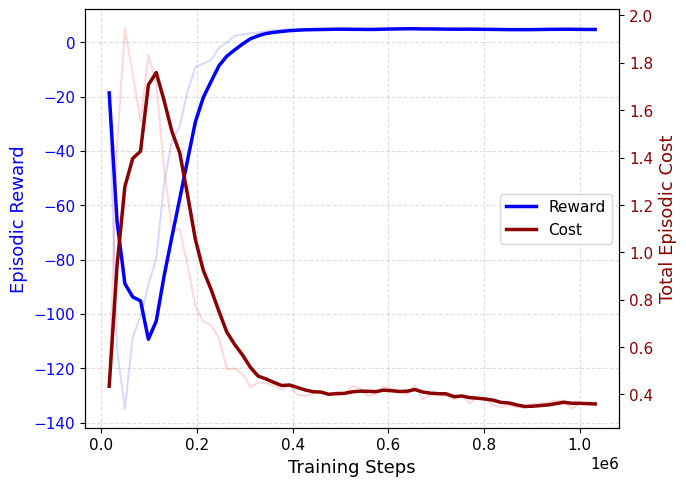

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TensorBoard CSV data
df_reward = pd.read_csv('reward.csv')
df_costs = pd.read_csv('costs.csv')

# Configure global plot parameters for consistent style
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11
})

# Smoothing parameter (window size 5)
window_size = 5
df_reward['Smoothed'] = df_reward['Value'].rolling(window=window_size, min_periods=1).mean()
df_costs['Smoothed'] = df_costs['Value'].rolling(window=window_size, min_periods=1).mean()

# Single plot with dual Y-axes
fig, ax1 = plt.subplots(figsize=(7, 5))

# Plot Reward on the Left Axis (ax1)
p1_raw, = ax1.plot(df_reward['Step'], df_reward['Value'], color='blue', alpha=0.15)
p1_smooth, = ax1.plot(df_reward['Step'], df_reward['Smoothed'], color='blue', linewidth=2.5, label='Reward')
ax1.set_xlabel('Training Steps')
ax1.set_ylabel('Episodic Reward', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

# Create second axis for Cost (ax2)
ax2 = ax1.twinx()
p2_raw, = ax2.plot(df_costs['Step'], df_costs['Value'], color='red', alpha=0.15)
p2_smooth, = ax2.plot(df_costs['Step'], df_costs['Smoothed'], color='darkred', linewidth=2.5, label='Cost')
ax2.set_ylabel('Total Episodic Cost', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

# Combined Legend for both axes
lns = [p1_smooth, p2_smooth]
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='center right')

plt.tight_layout()
plt.savefig('convergence_plot.png', dpi=300, bbox_inches='tight')